Useful Notes:

In Nielsen data, ACV stands for All Commodity Volume. It is a distribution measure, not market share. So if a product has 5% ACV, it means the product is sold in stores that represent 5% of the total measured market volume.
 It does not mean Niagara sold 5% of the market and competitors sold the other 95%. In simple terms, ACV tells us how widely the product is distributed, while sales or share
 
1. SKU Relationships
For this project, we can define “similar” or “adjacent” SKUs based on attributes that reflect how a consumer would compare products at shelf. The most important attributes to explore could be:
Same category, such as SUW compared with SUW or SFW compared with SFW
Similar brand or competing brands within the same category
Similar pack size or total size
Similar pack type, such as single bottle, multi-pack, or case pack
Similar flavor or unflavored profile
Similar use case, such as convenience, pantry loading, on-the-go, or premium/value positioning
Similar retailer or channel context, if available
Cannibalization is usually most meaningful within the same category, so start there first. For example, a new SUW SKU should first be compared with other SUW SKUs, especially those with similar pack sizes, pack types, or use cases. A new SFW SKU should first be compared with other SFW SKUs, especially those with similar flavor, pack size, or brand positioning.
That said, please also explore adjacent relationships across brands or product lines when the products serve a similar consumer need. The key is not only the hierarchy, but whether the products are realistic substitutes for each other.
 
2. Acronym Definitions
SUW - still unflavored water.
SFW - still flavored water.
These acronyms are important because they define major product segments in the Nielsen data. For the cannibalization analysis, SUW and SFW should generally be treated as separate segments first, since consumer substitution behavior is likely stronger within the same segment than across segments.
For example, a new Still Flavored Water SKU may cannibalize other SFW products more directly than Still Unflavored Water products. Similarly, a new SUW pack size or SKU should first be compared against other SUW products with similar brand, pack type, size, channel, and retailer context.
That said, again, cross-segment cannibalization can still be tested as a secondary analysis, especially if there is evidence that consumers substitute between flavored and unflavored water in a specific retailer, channel, or use case.
 
3. Product Hierarchy
For reference, the product hierarchy usually starts at a broad level and moves downward, such as:
Category → Brand → Pack Size / Pack Type → SKU
However, for the cannibalization analysis, you should not only rely on one fixed hierarchy. You can research and explore different hierarchy levels to understand where cannibalization is most likely happening.
In general, cannibalization within the same category is more valuable and more relevant to analyze than cross-category cannibalization. For example, products within Still Unflavored Water should generally be compared with other Still Unflavored Water products first, and products within Still Flavored Water should generally be compared with other Still Flavored Water products first.
Within the same category, cannibalization may happen in different ways (covered above as well):
Across brands with similar pack sizes or similar use cases.
Within the same brand across different sub-brands.
Within the same brand across different pack sizes or pack types.
Across similar SKUs that serve the same consumer need, even if they are not in the exact same sub-brand.
So instead of assuming the hierarchy is always linear, you should test multiple comparison groups. For example, you can compare SKU sales within the same category by brand, sub-brand, pack size, pack type, and similar product attributes.
 
4. Attribute Mapping
There is no direct Sub-Brand field in the current Nielsen dataset.
For this project, you can use brand as the closest available brand-level field, and use item, upc, flavor, pack_type, and pack size fields to define SKU similarity.
For cannibalization modeling, upc should be treated as the SKU-level identifier, while item provides the detailed product description.
 
5. Stockout
I would not recommend assuming that all observed sales represent unconstrained demand.
The Nielsen data reflects observed sales, not true consumer demand. If a product was out of stock or had limited availability, sales may drop even if consumer demand was still there. Without inventory, on-shelf availability, or out-of-stock indicators, we cannot fully separate true demand decline from supply constraints.
For this project, please treat sales as observed demand, not guaranteed unconstrained demand. This means a sales drop should not automatically be interpreted as cannibalization. It could also be caused by stockout, distribution changes, promotion changes, pricing, seasonality, or retailer execution.
A practical approach is to acknowledge this as a limitation and look for abnormal patterns, such as a sharp sales drop followed by a rebound, which may indicate possible stockout or supply disruption. If availability or distribution fields are available, they should be used as controls in the analysis.
 
6. Cannibalization
For cannibalization, we recommend starting the analysis at the SKU / UPC level and then rolling the results up to brand and category.
As mentioned above, cannibalization usually happens between specific products that consumers may substitute for each other, so SKU-level analysis is the most useful starting point. After that, you can aggregate the impact to understand the brand-level or category-level effect.
When we refer to “one category,” we generally mean that the first and most valuable analysis should happen within the same category. For example, SUW products should first be compared with other SUW products, and SFW products should first be compared with other SFW products. Cross-category cannibalization may exist, but it is usually less valuable as the primary focus.
Within the same category, please explore different possible cannibalization relationships. For example, cannibalization could happen across brands with similar pack sizes, within the same brand across different pack sizes, or within the same brand across different product lines or item types.
 
Please let me or Sid know if you have any further questions.
 

**Where this is applied in the notebook (Iteration 2):**
- Points 1-4 (SKU relationships, SUW/SFW acronyms, product hierarchy, attribute mapping) → Section 2 (segment defined from `niagara_personal_chars`, since SFW lives mostly under the raw `category == "VALUE ADD WATER"` bucket, not `"WATER"`) and Section 7 (multi-hierarchy substitute grouping: segment + brand + base_size + pack_type, tested against alternate hierarchies).
- Point 5 (stockout / observed demand) → Section 5.3 (sharp-drop-then-rebound screen) and the `peer_stockout_share` caveat carried into Sections 8-9.
- Point 6 (cannibalization: SKU up to brand/category) → Section 8 computes at the UPC level first, then rolls up to brand and segment (SUW vs. SFW) in Section 8.1.
- Additional statistical methods (OLS + 2 more, compared) → Section 6.1 (own-price elasticity: OLS vs. robust vs. quantile regression) and Section 7.1 (cannibalization signal: OLS vs. robust vs. quantile regression).

# Iteration 1

### Scope filter — WATER category only; classifies SKU-weeks as "pure price-discount" promos (excluding feature/display) using the price_decr_only_prc_acv share of any_promo_prc_acv.
### Baseline model — log-linear OLS with SKU fixed effects + seasonality/holiday controls, fit on non-promo weeks (R²=0.95), with VIF/residual diagnostics.
### Own-price elasticity: -0.121 (p<0.0001).
### Cross-SKU/cannibalization — grouped SKUs by brand + base_size + pack_type (closer substitutes than the raw pack_type field, which only has 2 values across 937 UPCs and would have mixed unrelated products together — I caught and fixed this after the first run produced nonsensical cannibalization rates).
### Cannibalization rate with proper denominators (excludes simultaneously-promoted peers, requires meaningful own lift) and robust statistics (median + sign test, since the raw ratio is heavy-tailed).
### Statistical validation + CSV exports to Analysis/outputs/ for the Power BI deliverable.


## Headline result: median cannibalization rate is -0.09 (mild halo), and peers lose volume in only 33.6% of promo events — significantly less than the 50% chance baseline (p<0.0001) — suggesting WATER price-discount promos are predominantly incremental, though ~20% of events show real cannibalization worth flagging for Category Management.

# Iteration 2

Incorporates the client feedback in the **Useful Notes** cell above:

### Scope fix — the Iteration 1 `category == "WATER"` filter silently dropped ~99% of SFW (Still Flavored Water) volume, because SFW products are tagged under the raw `category` value `"VALUE ADD WATER"`, not `"WATER"`. Segment is now defined from `niagara_personal_chars` (`PC_Total SUW` / `PC_Total SFW`), which correctly captures both segments regardless of the raw category bucket. This roughly doubles modeling rows and adds ~400 previously-invisible SFW UPCs.
### Segment-first hierarchy — SUW and SFW are treated as separate segments first (per Acronym Definitions), with substitute groups defined as `segment + brand + base_size + pack_type`. Two alternate hierarchies (cross-brand same-size, and cross-size same-brand) are tested for sensitivity, per the Product Hierarchy guidance to not rely on one fixed hierarchy.
### Stockout / observed-demand caveat — sales are treated as observed demand, not guaranteed unconstrained demand. A sharp-drop-then-rebound screen flags SKU-weeks that look like possible stockout/supply disruption, and the share of cannibalization events touching a flagged peer-week is reported as a caveat rather than silently dropped.
### SKU → brand → segment roll-up — cannibalization is computed at the UPC level first (per guidance point 6), then rolled up to brand and segment.
### Two additional statistical methods — robust regression (Huber's T) and quantile (median) regression are added alongside OLS for both the own-price elasticity model and the cross-SKU cannibalization-signal model, and compared side by side.

*(See the numbers in Section 10 / Key Findings below for this run's updated headline results — they differ from the Iteration 1 summary above because the modeling universe now includes SFW.)*

# Niagara Bottling — Promo Cannibalization Analysis (Still Water: SUW + SFW)

This notebook implements the modeling pipeline described in the project presentation:

- **Model Scope**: still-water segments only (SUW — Still Unflavored Water, and SFW — Still
  Flavored Water), identified via `niagara_personal_chars` rather than the raw `category` field
  (see Section 2). Pure price-discount promotions only (excludes feature/display).
- **Methodology**: baseline model → own-SKU elasticity (OLS + robust + quantile regression) →
  cross-SKU elasticity/cannibalization signal (OLS + robust + quantile regression) →
  cannibalization rate (UPC → brand → segment roll-up) → statistical validation
- **Goal**: determine whether price-discount promotions are incremental to category revenue or
  simply shift volume across Niagara's own SKUs, and whether that signal is consistent across
  SUW/SFW and across estimation methods

Builds on the data understanding established in `eda.ipynb`. See that notebook for full-dataset EDA across all six Nielsen categories.

## 1. Setup

In [5]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
np.random.seed(42)

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

## 2. Load Data & Filter to Model Scope

Per **Acronym Definitions** and **Attribute Mapping** in the Useful Notes: SUW and SFW are
Nielsen *segments*, not the same thing as the raw `category` field. Checking the data shows SFW
product is tagged under `category == "VALUE ADD WATER"`, not `"WATER"` — filtering on
`category == "WATER"` alone (Iteration 1) kept 99.7% SUW and only ~0.1% SFW rows, i.e. it
silently dropped almost the entire SFW segment. The field `niagara_personal_chars` tags every row
with its true segment (`PC_Total SUW` / `PC_Total SFW`) independent of which raw category bucket
it landed in, so we use that as the scope filter instead and carry `segment` forward as an
explicit column for all downstream grouping.

There is no direct Sub-Brand field in this dataset (Attribute Mapping note); `brand` is the
closest brand-level field, `upc` is treated as the SKU-level identifier, and `item` carries the
detailed product description.

In [ ]:
files = sorted(glob.glob("../data/bquxjob*.csv"))
print(f"Loading {len(files)} CSV files...")

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df["week_ending"] = pd.to_datetime(df["week_ending"])

# Segment via niagara_personal_chars (not the raw `category` field -- see markdown above).
SEGMENT_MAP = {"PC_Total SUW": "SUW", "PC_Total SFW": "SFW"}
water = df[df["niagara_personal_chars"].isin(SEGMENT_MAP)].copy()
water["segment"] = water["niagara_personal_chars"].map(SEGMENT_MAP)

print(f"Full dataset      : {df.shape[0]:,} rows")
print(f"SUW + SFW rows     : {water.shape[0]:,} rows")
print(f"Unique UPCs        : {water['upc'].nunique():,}")
print(f"Unique brands      : {water['brand'].nunique():,}")
print(f"Date range         : {water['week_ending'].min().date()} -> {water['week_ending'].max().date()}")

print("\nRows by segment x raw category (shows SFW living mostly under VALUE ADD WATER):")
print(water.groupby(["segment", "category"]).size().rename("rows"))

print("\nUnique UPCs by segment:")
print(water.groupby("segment")["upc"].nunique())

Loading 19 CSV files...
Full dataset      : 162,965 rows
SUW + SFW rows     : 82,458 rows
Unique UPCs        : 1,903
Unique brands      : 237
Date range         : 2025-01-04 -> 2026-02-21

Rows by segment x raw category (shows SFW living mostly under VALUE ADD WATER):
segment  category       
SFW      VALUE ADD WATER    21911
         WATER                 60
SUW      VALUE ADD WATER    18427
         WATER              41923
Name: rows, dtype: int64

Unique UPCs by segment:
segment
SFW     553
SUW    1350
Name: upc, dtype: int64


## 3. Promo Classification — Pure Price-Discount Only

The dataset breaks each row's ACV (`*_prc_acv`) into mutually exclusive promo mechanisms:
`no_promo`, `disp_wo_feat`, `feat_wo_disp`, `feat_n_disp`, and `price_decr_only`. These sum to
`any_promo_prc_acv`, which together with `no_promo_prc_acv` sums to total `acv`.

Per the **Model Scope** slide, we exclude feature and display promotions and analyze only
*pure price-discount* promo weeks. We classify a SKU-week as a pure price promo when:
- `promo_flag == 1` and `tpr_discount > 0` (a temporary price cut occurred), and
- `price_decr_only_prc_acv` accounts for the majority of `any_promo_prc_acv`
  (i.e. feature/display activity was not the dominant promo mechanism that week)

This classification is applied identically across both SUW and SFW segments.

In [ ]:
promo_components = [
    "disp_wo_feat_prc_acv", "feat_wo_disp_prc_acv", "feat_n_disp_prc_acv", "price_decr_only_prc_acv",
]
check = (water["any_promo_prc_acv"] - water[promo_components].sum(axis=1)).abs()
print(f"Max discrepancy between any_promo_prc_acv and component sum: {check.max():.6f}")

water["price_promo_share"] = np.where(
    water["any_promo_prc_acv"] > 0,
    water["price_decr_only_prc_acv"] / water["any_promo_prc_acv"],
    0.0,
)

water["pure_price_promo"] = (
    (water["promo_flag"] == 1)
    & (water["tpr_discount"] > 0)
    & (water["price_promo_share"] > 0.5)
).astype(int)

print(water["pure_price_promo"].value_counts())
print(f"\nShare of SUW+SFW SKU-weeks that are pure price-discount promos: "
      f"{water['pure_price_promo'].mean():.1%}")
print("\nPure price-promo share by segment:")
print(water.groupby("segment")["pure_price_promo"].mean())

Max discrepancy between any_promo_prc_acv and component sum: 0.000200
pure_price_promo
0    68734
1    13724
Name: count, dtype: int64

Share of SUW+SFW SKU-weeks that are pure price-discount promos: 16.6%

Pure price-promo share by segment:
segment
SFW   0.2540
SUW   0.1346
Name: pure_price_promo, dtype: float64


## 4. EDA Recap — SUW vs. SFW

A quick look at SKU distribution and promo prevalence within the still-water universe, split by
segment (the full cross-category EDA lives in `eda.ipynb`). Per the Acronym Definitions note,
SUW and SFW are treated as separate segments throughout.

In [ ]:
sku_summary = (
    water.groupby(["upc", "item", "brand", "segment", "flavor", "pack_type"])
    .agg(
        total_sales=("sales", "sum"),
        total_units=("units", "sum"),
        weeks_observed=("week_ending", "nunique"),
        promo_weeks=("pure_price_promo", "sum"),
        avg_aup=("aup", "mean"),
    )
    .sort_values("total_sales", ascending=False)
)
sku_summary["promo_week_pct"] = sku_summary["promo_weeks"] / sku_summary["weeks_observed"]
print(f"Total SUW+SFW SKUs: {len(sku_summary):,}")
sku_summary.head(15)

Total SUW+SFW SKUs: 1,940


,,,,,,total_sales,total_units,weeks_observed,promo_weeks,avg_aup,promo_week_pct
upc,item,brand,segment,flavor,pack_type,,,,,,
200042158786,CTL BR DRNK WTR BTL 40PK 16.9 FL OZ,PRIVATE LABEL,SUW,UNFLAVORED,MULTI PACK,25579734.6279,4780306.9228,60,7,5.3687,0.1167
7514000515,CRYS GYS CG RXN SRC ALPN SPRN SPRN WTR BTL 128 FL OZ,CRYSTAL GEYSER (CG ROXANE LLC),SUW,UNFLAVORED,SINGLE PACK,15953337.6616,10744870.5962,60,1,1.4867,0.0167
200077939964,CTL BR DRNK WTR BTL 40PK 16.9 FL OZ,PRIVATE LABEL,SUW,UNFLAVORED,MULTI PACK,12721220.0181,2561203.3580,60,0,4.9667,0.0000
200028562169,CTL BR DRNK WTR BTL 40PK 16.9 FL OZ,PRIVATE LABEL,SUW,UNFLAVORED,MULTI PACK,9105976.5563,2288336.1027,60,0,3.9788,0.0000
7514035001,CRYS GYS ALPN SPRN WTR BTL 35PK 16.9 FL OZ,CRYSTAL GEYSER (CG ROXANE LLC),SUW,UNFLAVORED,MULTI PACK,8917661.2931,1449478.9513,60,4,6.1593,0.0667
7114200400,ARWH MNTN SPRN WTR BTL 24PK 16.9 FL OZ,ARROWHEAD (PRIMO BRANDS CORPORATION),SUW,UNFLAVORED,MULTI PACK,7298197.1373,1277367.0671,60,19,5.7298,0.3167
200205694247,CTL BR DRNK WTR BTL 40PK 16.9 FL OZ,PRIVATE LABEL,SUW,UNFLAVORED,MULTI PACK,6978239.4524,1467252.7013,59,0,4.7493,0.0000
200029055192,CTL BR DRNK WTR BTL 24PK 16.9 FL OZ,PRIVATE LABEL,SUW,UNFLAVORED,MULTI PACK,6976619.6502,2186347.5797,60,0,3.1941,0.0000
4900003165,DSN DRNK WTR BTL 24PK 16.9 FL OZ,DASANI (COCA-COLA COMPANY),SUW,UNFLAVORED,MULTI PACK,5519459.1517,953568.5613,60,21,5.8490,0.3500


In [ ]:
brand_summary = (
    water.groupby("brand")
    .agg(total_sales=("sales", "sum"), unique_upcs=("upc", "nunique"), avg_aup=("aup", "mean"))
    .sort_values("total_sales", ascending=False)
)
brand_summary.head(10)

,total_sales,unique_upcs,avg_aup
brand,,,
PRIVATE LABEL,159577406.7919,549,3.5073
CRYSTAL GEYSER (CG ROXANE LLC),45122521.1253,32,5.7527
ARROWHEAD (PRIMO BRANDS CORPORATION),26854212.0469,52,5.8758
"GLACEAU SMART WATER (ENERGY BRANDS, INC.)",22177635.0784,44,9.0102
"GLACEAU VITAMIN WATER (ENERGY BRANDS, INC.)",21793200.3925,54,6.2654
PURE LIFE (PRIMO BRANDS CORPORATION),16890281.0435,48,6.4755
AQUAFINA (PEPSI COLA CO/DIV PEPSICO INC),13195999.2691,16,3.3322
DASANI (COCA-COLA COMPANY),11838280.3965,18,3.8816
FIJI (NATURAL WATERS OF VITI LIMITED),10299236.0399,19,14.5159


### 4.1 SUW vs. SFW Segment Summary

SFW is the smaller segment by sales but is not negligible, and it was almost entirely missing
from the Iteration 1 (`category == "WATER"`) scope.

In [ ]:
segment_summary = (
    water.groupby("segment")
    .agg(
        total_sales=("sales", "sum"),
        total_units=("units", "sum"),
        unique_upcs=("upc", "nunique"),
        unique_brands=("brand", "nunique"),
        avg_aup=("aup", "mean"),
        pure_price_promo_share=("pure_price_promo", "mean"),
    )
    .sort_values("total_sales", ascending=False)
)
segment_summary["sales_share"] = segment_summary["total_sales"] / segment_summary["total_sales"].sum()
segment_summary

,total_sales,total_units,unique_upcs,unique_brands,avg_aup,pure_price_promo_share,sales_share
segment,,,,,,,
SUW,366450672.1867,112530859.6486,1350,178,4.9669,0.1346,0.9077
SFW,37275856.3189,12675355.6771,553,82,5.2196,0.2540,0.0923


## 5. Baseline Model

Per **Methodology** and **Modeling & Analysis**: establish a clean baseline for each SKU
representing expected sales in the absence of promotion, using a multiple log-linear regression
(as suggested in the Analytics slide) on non-promo weeks. Controls include seasonality and
holiday effects; SKU (`upc`) fixed effects capture cross-sectional differences in base velocity.
Because `upc` is nested within `segment` (every UPC is either SUW or SFW, never both), the SKU
fixed effects already absorb any segment-level baseline difference — a separate `segment` term
would be redundant here.

We restrict the analysis universe to SKUs with sufficient observations (>= 20 weeks) so
fixed-effect and elasticity estimates are not driven by sparsely observed items.

In [ ]:
sku_counts = water.groupby("upc")["week_ending"].nunique()
eligible_upcs = sku_counts[sku_counts >= 20].index
model_df = water[water["upc"].isin(eligible_upcs)].copy()
model_df["log_units"] = np.log(model_df["units"].clip(lower=1e-6))
model_df["log_price"] = np.log(model_df["aup"].clip(lower=1e-6))
model_df["upc"] = model_df["upc"].astype(str)

print(f"Eligible SKUs (>=20 weeks observed): {len(eligible_upcs):,}")
print(f"Modeling rows: {len(model_df):,}")
print("\nEligible SKUs by segment:")
print(model_df.groupby("segment")["upc"].nunique())

Eligible SKUs (>=20 weeks observed): 1,474
Modeling rows: 78,904

Eligible SKUs by segment:
segment
SFW     395
SUW    1079
Name: upc, dtype: int64


In [ ]:
baseline_train = model_df[model_df["pure_price_promo"] == 0]

baseline_model = smf.ols(
    "log_units ~ C(upc) + seasonality_index + tpr_discount + Holiday_4th_of_July "
    "+ Holiday_Thanksgiving_Day + Holiday_Christmas_Day + Holiday_New_Year_s_Day",
    data=baseline_train,
).fit()

print(baseline_model.summary().tables[0])
print(f"\nR-squared: {baseline_model.rsquared:.3f}")
print(f"N obs    : {int(baseline_model.nobs):,}")

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     556.2
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:46:45   Log-Likelihood:                -64499.
No. Observations:               58259   AIC:                         1.319e+05
Df Residuals:                   56783   BIC:                         1.452e+05
Df Model:                        1475                                         
Covariance Type:            nonrobust                                         

R-squared: 0.935
N obs    : 58,259


### 5.1 Baseline Diagnostics

Per the Analytics slide: *"Perform diagnostics on the baseline model to determine whether the
selected model type appropriately fits the dataset."* We check residual behavior and
multicollinearity among the continuous controls.

In [ ]:
resid = baseline_model.resid
fitted = baseline_model.fittedvalues

print("Residual summary:")
print(resid.describe())

# Multicollinearity check on the continuous (non-fixed-effect) regressors
vif_data = baseline_train[["seasonality_index", "tpr_discount"]].dropna()
vif_data = sm.add_constant(vif_data)
vif = pd.Series(
    [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])],
    index=vif_data.columns,
)
print("\nVIF (continuous controls):")
print(vif)

Residual summary:
count   58259.0000
mean        0.0000
std         0.7321
min        -7.3050
25%        -0.1618
50%         0.0118
75%         0.2173
max         6.0000
dtype: float64

VIF (continuous controls):
const               91.2125
seasonality_index    1.0002
tpr_discount         1.0002
dtype: float64


In [ ]:
model_df["log_units_hat"] = baseline_model.predict(model_df)
model_df["baseline_units"] = np.exp(model_df["log_units_hat"])
model_df["lift_units"] = model_df["units"] - model_df["baseline_units"]
model_df["lift_pct"] = model_df["lift_units"] / model_df["baseline_units"]

print("Own-SKU lift in promo vs non-promo weeks:")
print(model_df.groupby("pure_price_promo")["lift_pct"].mean())

Own-SKU lift in promo vs non-promo weeks:
pure_price_promo
0   0.4257
1   1.9304
Name: lift_pct, dtype: float64


### 5.3 Observed-Demand Caveat — Stockout / Availability Screen

Per the **Stockout** note: this dataset has no inventory, on-shelf-availability, or
out-of-stock indicator, so we cannot fully separate a true demand decline from a supply
constraint. Sales here are treated as *observed* demand, not guaranteed *unconstrained* demand —
a sales drop is not automatically interpreted as cannibalization; it can also come from
stockout, distribution changes, promotion changes, pricing, seasonality, or retailer execution.

As a practical, data-only proxy (no availability field to control on), we flag SKU-weeks with an
abnormal pattern: a sharp drop vs. the SKU's own trailing 4-week average, in a non-promo week,
immediately followed by a rebound the next week. This pattern is consistent with a stockout/supply
disruption rather than a genuine demand shift, and is *not* used to drop rows (that would bias the
baseline) — it is carried forward as `possible_stockout_flag` and surfaced as a caveat wherever it
could be confused with a cannibalization/halo signal (Sections 8-9).

In [ ]:
model_df = model_df.sort_values(["upc", "week_ending"])

trailing_avg = (
    model_df.groupby("upc")["units"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
)
model_df["pct_vs_trailing_avg"] = (model_df["units"] - trailing_avg) / trailing_avg

units_next = model_df.groupby("upc")["units"].shift(-1)
model_df["rebound_pct"] = (units_next - model_df["units"]) / model_df["units"].clip(lower=1e-6)

STOCKOUT_DROP_THRESHOLD = -0.50
STOCKOUT_REBOUND_THRESHOLD = 0.50

model_df["possible_stockout_flag"] = (
    (model_df["pct_vs_trailing_avg"] <= STOCKOUT_DROP_THRESHOLD)
    & (model_df["pure_price_promo"] == 0)
    & (model_df["rebound_pct"] >= STOCKOUT_REBOUND_THRESHOLD)
)

print(f"SKU-weeks flagged as possible stockout/rebound: "
      f"{model_df['possible_stockout_flag'].sum():,} "
      f"({model_df['possible_stockout_flag'].mean():.2%} of modeling rows)")
print("\nBy segment:")
print(model_df.groupby("segment")["possible_stockout_flag"].mean())

SKU-weeks flagged as possible stockout/rebound: 3,487 (4.42% of modeling rows)

By segment:
segment
SFW   0.0465
SUW   0.0434
Name: possible_stockout_flag, dtype: float64


### 5.2 OLS Model Assumption Diagnostics

Perform OLS model diagnostics on the baseline model.  Check for 1) Linearity, 2) Constant Variance and Uncorrelated Errors, and 3) Normality.

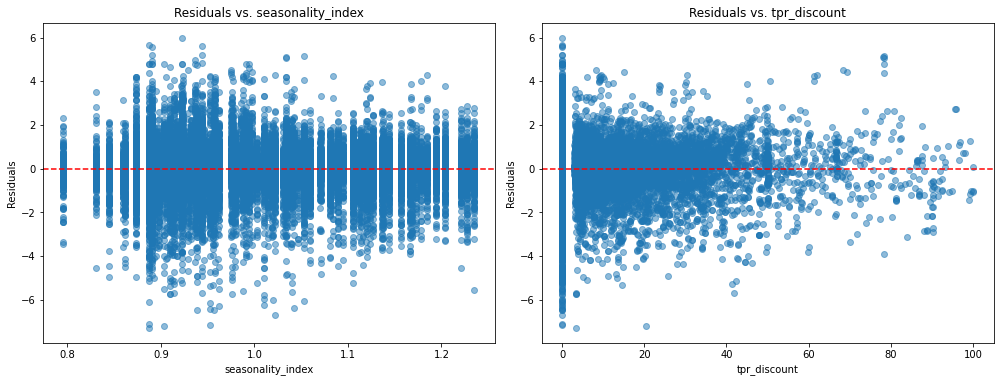

In [ ]:
# Verify whether the linearity assumption holds for continuous, quantitative predictors in the model

# Derive the df that was used by statsmodels for model fitting
diag_df = baseline_train.loc[baseline_model.model.data.row_labels]

# Calculate the residuals
residuals = baseline_model.resid

# Create scatter plots of the residuals vs. the quantitative predictors
plt.figure(figsize=(14, 10))

# Scatter plot for seasonality_index
plt.subplot(2, 2, 1)
plt.scatter(diag_df["seasonality_index"], residuals, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("seasonality_index")
plt.ylabel("Residuals")
plt.title("Residuals vs. seasonality_index")


# Scatter plot for tpr_discount
plt.subplot(2, 2, 2)
plt.scatter(diag_df["tpr_discount"], residuals, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("tpr_discount")
plt.ylabel("Residuals")
plt.title("Residuals vs. tpr_discount")


plt.tight_layout()
plt.show()

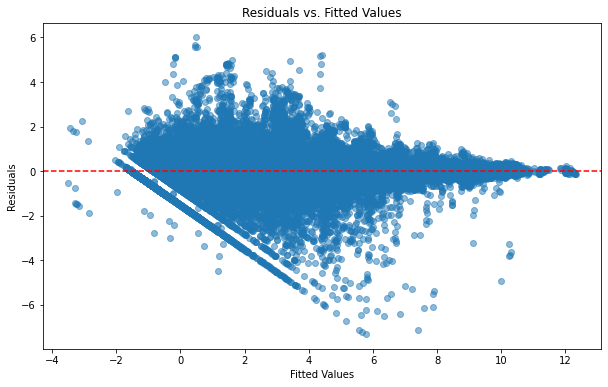

In [ ]:
# Verify whether the constant variance and uncorrelated errors assumptions hold
# Calculate the fitted values
fitted_values = baseline_model.fittedvalues

# Create scatterplot of standardized residuals vs. fitted values
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

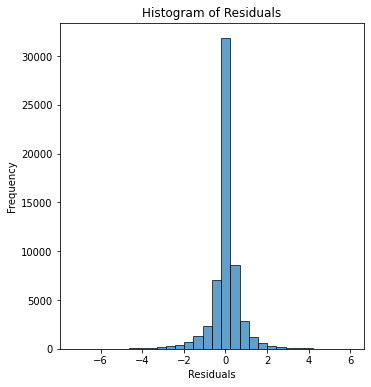

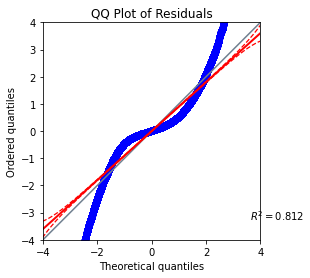

In [ ]:
# Verify whether the normality assumption holds
# Create a histogram of the standardized residuals
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

# Display the plot
plt.show()

# Generate QQ plot
ax = pg.qqplot(residuals, dist='norm', confidence=.95)
ax.set_title('QQ Plot of Residuals')

# Set the axis limits
ax.set_xlim([-4, +4])
ax.set_ylim([-4, +4])

# Display the plot
plt.show()

## 6. Own-SKU Price Elasticity

For each promoted SKU, estimate how its own sales respond to its own price changes
(own-price elasticity), using within-SKU price variation driven by promotions. `model_df` now
spans both SUW and SFW; SKU (`upc`) fixed effects mean each SKU is only ever compared to its own
history, so pooling both segments here does not mix unrelated products.

In [ ]:
own_elasticity_model = smf.ols(
    "log_units ~ C(upc) + log_price + seasonality_index",
    data=model_df,
).fit()

print(f"Own-price elasticity (avg across SKUs): {own_elasticity_model.params['log_price']:.3f}")
print(f"p-value: {own_elasticity_model.pvalues['log_price']:.4f}")
print(f"R-squared: {own_elasticity_model.rsquared:.3f}")

Own-price elasticity (avg across SKUs): -0.318
p-value: 0.0000
R-squared: 0.930


### 6.1 Method Comparison — OLS vs. Robust vs. Quantile Regression

In addition to OLS, we re-estimate the own-price elasticity with two more statistical methods
and compare the results:

- **Robust regression (Huber's T, IRLS)** — down-weights outlier SKU-weeks (e.g. the
  stockout/rebound weeks flagged in 5.3) so a handful of extreme observations don't distort the
  elasticity the way they can under OLS's squared-error loss.
- **Quantile regression (median, q=0.5)** — estimates the elasticity at the conditional *median*
  of `log_units` rather than the mean, which is naturally robust to the skewed, heavy-tailed sales
  distribution we already see elsewhere in this notebook (e.g. the cannibalization-rate ratio in
  Section 8).

Fitting `C(upc)` directly would require ~1,400 dummy columns, which is expensive for the
iterative solvers robust/quantile regression use. Instead we apply the standard **within
transformation**: demean `log_units`, `log_price`, and `seasonality_index` by `upc` first, then
fit each method on the demeaned data. This is algebraically equivalent to including SKU fixed
effects directly (the OLS-within slope below should closely match the `log_price` coefficient
from the `C(upc)` model above) but keeps the design matrix small enough for all three estimators
to run quickly.

In [ ]:
demean_cols = ["log_units", "log_price", "seasonality_index"]
within = model_df[["upc"] + demean_cols].dropna().copy()
for col in demean_cols:
    within[f"{col}_dm"] = within[col] - within.groupby("upc")[col].transform("mean")

ols_within = smf.ols("log_units_dm ~ log_price_dm + seasonality_index_dm", data=within).fit()
rlm_within = smf.rlm(
    "log_units_dm ~ log_price_dm + seasonality_index_dm", data=within, M=sm.robust.norms.HuberT()
).fit()
qr_within = smf.quantreg("log_units_dm ~ log_price_dm + seasonality_index_dm", data=within).fit(q=0.5)

elasticity_comparison = pd.DataFrame(
    {
        "method": ["OLS (within)", "Robust regression - Huber's T (within)", "Quantile regression - median (within)"],
        "own_price_elasticity": [
            ols_within.params["log_price_dm"],
            rlm_within.params["log_price_dm"],
            qr_within.params["log_price_dm"],
        ],
        "p_value": [
            ols_within.pvalues["log_price_dm"],
            rlm_within.pvalues["log_price_dm"],
            qr_within.pvalues["log_price_dm"],
        ],
        "seasonality_coef": [
            ols_within.params["seasonality_index_dm"],
            rlm_within.params["seasonality_index_dm"],
            qr_within.params["seasonality_index_dm"],
        ],
    }
)
print(f"For reference, OLS with explicit C(upc) fixed effects (Section 6): "
      f"log_price coef = {own_elasticity_model.params['log_price']:.4f}")
elasticity_comparison

For reference, OLS with explicit C(upc) fixed effects (Section 6): log_price coef = -0.3180


,method,own_price_elasticity,p_value,seasonality_coef
0,OLS (within),-0.3180,0.0000,0.9353
1,Robust regression - Huber's T (within),-0.7231,0.0000,0.9651
2,Quantile regression - median (within),-0.8138,0.0000,0.9188


## 7. Cross-SKU Elasticity & Cannibalization Grouping

Per **Methodology**, **SKU Relationships**, and **Product Hierarchy**: cannibalization is most
meaningful within the same segment, so we split by `segment` (SUW vs. SFW) first, then by the
attributes a shopper would actually compare at shelf. `pack_type` alone is too coarse (only 3
values across ~1,900 UPCs) — grouping by it would mix hundreds of unrelated brands/sizes together
and treat their unrelated week-to-week noise as if it were cannibalization.

Per the guidance to *"test multiple comparison groups"* rather than assume one fixed hierarchy,
we build three candidate substitute-group definitions and compare their coverage:

1. **`segment + brand + base_size + pack_type`** (primary) — closest shelf substitutes: same
   segment, same brand, same size, same pack type (e.g. different flavors/UPCs of one SKU line).
2. **`segment + base_size + pack_type`** (cross-brand) — tests cannibalization *across brands*
   with similar pack size, per the Product Hierarchy note.
3. **`segment + brand + pack_type`** (cross-size) — tests cannibalization *within the same brand*
   across different pack sizes.

The primary grouping (1) is used for the SKU-level cannibalization-rate calculation in Section 8;
groupings (2) and (3) are reported here as a sensitivity check on how much substitute-group
coverage changes under a different hierarchy.

We then build a week x substitute-group panel and measure how a promoted SKU's discount affects
the *net* volume of its substitute group (excluding itself) during the same week.

In [ ]:
HIERARCHIES = {
    "segment_brand_size_pack (primary)": ["segment", "brand", "base_size", "pack_type"],
    "segment_size_pack (cross-brand)": ["segment", "base_size", "pack_type"],
    "segment_brand_pack (cross-size)": ["segment", "brand", "pack_type"],
}

hierarchy_coverage = []
for name, cols in HIERARCHIES.items():
    grp_id = model_df[cols].astype(str).agg("|".join, axis=1)
    sizes = model_df.assign(_grp=grp_id).groupby("_grp")["upc"].nunique()
    multi = sizes[sizes >= 2]
    hierarchy_coverage.append(
        {
            "hierarchy": name,
            "n_groups": sizes.shape[0],
            "n_multi_sku_groups": len(multi),
            "row_coverage": model_df.assign(_grp=grp_id)["_grp"].isin(multi.index).mean(),
        }
    )
hierarchy_coverage = pd.DataFrame(hierarchy_coverage)
print(hierarchy_coverage)

# Primary hierarchy drives the SKU-level cannibalization-rate calc in Section 8
GROUP_COLS = HIERARCHIES["segment_brand_size_pack (primary)"]
model_df["sub_group"] = model_df[GROUP_COLS].astype(str).agg("|".join, axis=1)

group_sizes = model_df.groupby("sub_group")["upc"].nunique()
print(f"\nPrimary hierarchy substitute groups: {group_sizes.shape[0]:,}")
print(group_sizes.describe())

# Only groups with at least 2 SKUs have a meaningful peer to cannibalize
multi_sku_groups = group_sizes[group_sizes >= 2].index
print(f"\nGroups with >=2 SKUs: {len(multi_sku_groups):,} "
      f"({model_df['sub_group'].isin(multi_sku_groups).mean():.1%} of rows)")

                           hierarchy  n_groups  n_multi_sku_groups  \
0  segment_brand_size_pack (primary)       617                 206   
1    segment_size_pack (cross-brand)       145                  94   
2    segment_brand_pack (cross-size)       287                 176   

   row_coverage  
0        0.7237  
1        0.9685  
2        0.9312  

Primary hierarchy substitute groups: 617
count   617.0000
mean      2.3890
std       6.4811
min       1.0000
25%       1.0000
50%       1.0000
75%       2.0000
max     109.0000
Name: upc, dtype: float64

Groups with >=2 SKUs: 206 (72.4% of rows)


In [ ]:
panel = (
    model_df.groupby(["sub_group", "week_ending"])
    .agg(
        group_units=("units", "sum"),
        group_baseline=("baseline_units", "sum"),
        promo_intensity=("pure_price_promo", "mean"),
    )
    .reset_index()
)
panel["group_lift_pct"] = (panel["group_units"] - panel["group_baseline"]) / panel["group_baseline"]
panel = panel[panel["sub_group"].isin(multi_sku_groups)]

cross_model = smf.ols("group_lift_pct ~ promo_intensity", data=panel).fit()
print(cross_model.summary().tables[1])

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2514      0.031      8.160      0.000       0.191       0.312
promo_intensity     1.0892      0.086     12.636      0.000       0.920       1.258


### 7.1 Method Comparison — Is the Cannibalization Signal Robust to Estimation Method?

`group_lift_pct` is a ratio (bounded below at -1, unbounded above) with a right skew, so it is a
good candidate for the same OLS vs. robust vs. quantile comparison used in 6.1 — this time
applied directly to the cross-SKU cannibalization signal itself rather than to own-price
elasticity. This panel is small (one row per substitute-group-week), so no within-transformation
is needed here.

In [ ]:
rlm_cross = smf.rlm("group_lift_pct ~ promo_intensity", data=panel, M=sm.robust.norms.HuberT()).fit()
qr_cross = smf.quantreg("group_lift_pct ~ promo_intensity", data=panel).fit(q=0.5)

cross_comparison = pd.DataFrame(
    {
        "method": ["OLS", "Robust regression - Huber's T", "Quantile regression - median"],
        "promo_intensity_coef": [
            cross_model.params["promo_intensity"],
            rlm_cross.params["promo_intensity"],
            qr_cross.params["promo_intensity"],
        ],
        "p_value": [
            cross_model.pvalues["promo_intensity"],
            rlm_cross.pvalues["promo_intensity"],
            qr_cross.pvalues["promo_intensity"],
        ],
        "intercept": [
            cross_model.params["Intercept"],
            rlm_cross.params["Intercept"],
            qr_cross.params["Intercept"],
        ],
    }
)
cross_comparison

,method,promo_intensity_coef,p_value,intercept
0,OLS,1.0892,0.0000,0.2514
1,Robust regression - Huber's T,0.3499,0.0000,0.0375
2,Quantile regression - median,0.3038,0.0000,0.0165


## 8. Cannibalization Rate

Per **Modeling & Analysis**: *"Calculate cannibalization rates by comparing lost volume in
non-promoted SKUs to lift in the promoted one."*

Per guidance point 6 (**Cannibalization**), we start at the SKU/UPC level and roll results up to
brand and segment afterward (Section 8.1) — cannibalization happens between specific products
consumers substitute for each other, so SKU-level detail is the useful primary output; brand and
segment totals are an aggregation of it, not a separate analysis.

For each promo week of a focal SKU (restricted to substitute groups with >=2 SKUs, using the
primary segment-first hierarchy from Section 7), we compute:
- **Own lift** = actual - baseline units for the promoted SKU, restricted to events with a
  *meaningful* lift (>= 10% above baseline) so the denominator isn't dominated by noise
- **Peer net change** = (actual - baseline) units summed across *non-promoted* peer SKUs in the
  same substitute group that same week. We exclude peers that are simultaneously running their
  own price promo, since their own lift would otherwise be misattributed as a halo/cannibalization
  effect from the focal SKU
- **Cannibalization rate** = -peer net change / own lift
  (0 = fully incremental with no spillover, 1 = fully cannibalized within the group,
  negative = halo effect where peers also gained, >1 = promo shrank the substitute group)
- **`peer_stockout_share`** = share of that week's peer rows carrying the `possible_stockout_flag`
  from Section 5.3 — a caveat flag, not a filter: events with a high share should be treated with
  extra caution, since an apparent "cannibalization" could instead be a peer stockout that week

Because this is a ratio of two noisy quantities, the **mean** is not a robust summary statistic
(a handful of near-zero denominators can dominate it) — we report the **median** and an
**aggregate-level rate** (total peer net change / total own lift across all events) as the
primary metrics, and flag the per-event distribution only for sensitivity context.

In [ ]:
def cannibalization_rate(frame, valid_groups, min_lift_pct=0.10):
    promo_rows = frame[
        (frame["pure_price_promo"] == 1)
        & (frame["sub_group"].isin(valid_groups))
        & (frame["lift_pct"] >= min_lift_pct)
    ]
    results = []
    for _, row in promo_rows.iterrows():
        own_lift = row["lift_units"]
        peers = frame[
            (frame["sub_group"] == row["sub_group"])
            & (frame["week_ending"] == row["week_ending"])
            & (frame["upc"] != row["upc"])
            & (frame["pure_price_promo"] == 0)
        ]
        if peers.empty:
            continue
        peer_net_change = peers["lift_units"].sum()
        results.append(
            {
                "upc": row["upc"],
                "item": row["item"],
                "brand": row["brand"],
                "segment": row["segment"],
                "week_ending": row["week_ending"],
                "sub_group": row["sub_group"],
                "own_lift": own_lift,
                "peer_net_change": peer_net_change,
                "cannibalization_rate": -peer_net_change / own_lift,
                "peer_stockout_share": peers["possible_stockout_flag"].mean(),
            }
        )
    return pd.DataFrame(results)

cannibalization_events = cannibalization_rate(model_df, multi_sku_groups)
print(f"Promo events analyzed: {len(cannibalization_events):,}")
cannibalization_events["cannibalization_rate"].describe()

Promo events analyzed: 5,342


count     5342.0000
mean       -66.2013
std       1917.0569
min     -99614.9462
25%         -2.6247
50%         -0.1020
75%          0.0669
max      56449.3864
Name: cannibalization_rate, dtype: float64

In [ ]:
summary = pd.DataFrame(
    {
        "n_events": [len(cannibalization_events)],
        "median_rate": [cannibalization_events["cannibalization_rate"].median()],
        "iqr_low": [cannibalization_events["cannibalization_rate"].quantile(0.25)],
        "iqr_high": [cannibalization_events["cannibalization_rate"].quantile(0.75)],
        "pct_halo (rate<0)": [(cannibalization_events["cannibalization_rate"] < 0).mean()],
        "pct_partial_cannibalization (0<=rate<1)": [
            cannibalization_events["cannibalization_rate"].between(0, 1).mean()
        ],
        "pct_full_or_over_cannibalization (rate>=1)": [
            (cannibalization_events["cannibalization_rate"] >= 1).mean()
        ],
        "pct_events_with_stockout_risk_peer": [(cannibalization_events["peer_stockout_share"] > 0).mean()],
        "total_own_lift": [cannibalization_events["own_lift"].sum()],
        "total_peer_net_change": [cannibalization_events["peer_net_change"].sum()],
    }
)
summary["aggregate_cannibalization_rate"] = (
    -summary["total_peer_net_change"] / summary["total_own_lift"]
)
summary["net_group_lift"] = summary["total_own_lift"] + summary["total_peer_net_change"]
summary

,n_events,median_rate,iqr_low,iqr_high,pct_halo (rate<0),pct_partial_cannibalization (0<=rate<1),pct_full_or_over_cannibalization (rate>=1),pct_events_with_stockout_risk_peer,total_own_lift,total_peer_net_change,aggregate_cannibalization_rate,net_group_lift
0,5342,-0.1020,-2.6247,0.0669,0.6082,0.2355,0.1563,0.3276,2245138.2843,7269758.1422,-3.2380,9514896.4266


### 8.1 Roll-Up: SKU → Brand → Segment

Per guidance point 6, the SKU-level events above are now aggregated up to brand and to segment
(SUW vs. SFW), using the aggregate rate (sum of peer net change / sum of own lift) rather than
averaging the per-event ratios, for the same robustness reason as the overall `summary` above.

In [ ]:
def rollup(frame, by):
    g = frame.groupby(by).agg(
        n_events=("cannibalization_rate", "size"),
        median_rate=("cannibalization_rate", "median"),
        total_own_lift=("own_lift", "sum"),
        total_peer_net_change=("peer_net_change", "sum"),
    )
    g["aggregate_cannibalization_rate"] = -g["total_peer_net_change"] / g["total_own_lift"]
    return g.sort_values("total_own_lift", ascending=False)

segment_rollup = rollup(cannibalization_events, "segment")
print("Segment roll-up:")
display(segment_rollup)

brand_rollup = rollup(cannibalization_events, ["segment", "brand"])
print("\nTop 10 brands by own lift:")
display(brand_rollup.head(10))

Segment roll-up:


,n_events,median_rate,total_own_lift,total_peer_net_change,aggregate_cannibalization_rate
segment,,,,,
SUW,2375,-0.0358,1301107.4629,5699867.5608,-4.3808
SFW,2967,-0.1756,944030.8214,1569890.5814,-1.6630



Top 10 brands by own lift:


n_events  median_rate  \
segment brand                                                                
SFW     GLACEAU VITAMIN WATER (ENERGY BRANDS, INC.)       388      -1.3198   
SUW     PRIVATE LABEL                                     984      -3.9866   
SFW     HINT (HINT INC)                                   895      -0.2380   
SUW     ARROWHEAD (PRIMO BRANDS CORPORATION)              143      -0.0000   
        GLACEAU SMART WATER (ENERGY BRANDS, INC.)          95      -0.0007   
        CORE HYDRATION (CORE NUTRITION, LLC)              105      -0.0000   
        CRYSTAL GEYSER (CG ROXANE LLC)                    124      -0.0173   
        DASANI (COCA-COLA COMPANY)                         49      -0.0000   
        PURE LIFE (PRIMO BRANDS CORPORATION)              138      -0.0333   
SFW     PROPEL (THE GATORADE COMPANY)                     474      -0.2233   

                                                     total_own_lift  \
segment brand                                                         
SFW     GLACEAU VITAMIN WATER (ENERGY BRANDS, INC.)     503498.9436   
SUW     PRIVATE LABEL                                   435800.0187   
SFW     HINT (HINT INC)                                 215078.8085   
SUW     ARROWHEAD (PRIMO BRANDS CORPORATION)            139083.1118   
        GLACEAU SMART WATER (ENERGY BRANDS, INC.)       126492.8056   
        CORE HYDRATION (CORE NUTRITION, LLC)            109647.1281   
        CRYSTAL GEYSER (CG ROXANE LLC)                  105661.0428   
        DASANI (COCA-COLA COMPANY)                       89244.8872   
        PURE LIFE (PRIMO BRANDS CORPORATION)             84228.8410   
SFW     PROPEL (THE GATORADE COMPANY)                    80503.5616   

                                                     total_peer_net_change  \
segment brand                                                                
SFW     GLACEAU VITAMIN WATER (ENERGY BRANDS, INC.)           1220723.3750   
SUW     PRIVATE LABEL                                         5567415.0161   
SFW     HINT (HINT INC)                                        155875.6098   
SUW     ARROWHEAD (PRIMO BRANDS CORPORATION)                    14595.5011   
        GLACEAU SMART WATER (ENERGY BRANDS, INC.)               38102.9558   
        CORE HYDRATION (CORE NUTRITION, LLC)                    11445.2440   
        CRYSTAL GEYSER (CG ROXANE LLC)                         -38292.1196   
        DASANI (COCA-COLA COMPANY)                              -5708.6429   
        PURE LIFE (PRIMO BRANDS CORPORATION)                    75425.1654   
SFW     PROPEL (THE GATORADE COMPANY)                          102712.7616   

                                                     aggregate_cannibalization_rate  
segment brand                                                                        
SFW     GLACEAU VITAMIN WATER (ENERGY BRANDS, INC.)                         -2.4245  
SUW     PRIVATE LABEL                                                      -12.7752  
SFW     HINT (HINT INC)                                                     -0.7247  
SUW     ARROWHEAD (PRIMO BRANDS CORPORATION)                                -0.1049  
        GLACEAU SMART WATER (ENERGY BRANDS, INC.)                           -0.3012  
        CORE HYDRATION (CORE NUTRITION, LLC)                                -0.1044  
        CRYSTAL GEYSER (CG ROXANE LLC)                                       0.3624  
        DASANI (COCA-COLA COMPANY)                                           0.0640  
        PURE LIFE (PRIMO BRANDS CORPORATION)                                -0.8955  
SFW     PROPEL (THE GATORADE COMPANY)                                       -1.2759

## 9. Statistical Validation

Confirm the cannibalization signal is real rather than noise. Because the per-event rate
distribution is heavy-tailed (ratio of two noisy quantities), we use a **sign test** (non-parametric,
robust to outliers) on whether peer SKUs lose volume more often than chance during focal-SKU promo
weeks, plus a paired comparison of peer lift_pct in promo vs. non-promo weeks.

Per the **Stockout** note, we also check whether the signal survives excluding events whose peers
carry any stockout-risk flag (Section 5.3 / 8), as a sensitivity check on whether the result is
being driven by apparent "cannibalization" that may actually be a peer supply disruption.

In [ ]:
from scipy import stats

rates = cannibalization_events["cannibalization_rate"].dropna()

# Sign test: is peer_net_change negative (i.e. true cannibalization, not halo) more often than not?
n_neg = (cannibalization_events["peer_net_change"] < 0).sum()
n_total = len(cannibalization_events)
sign_test = stats.binomtest(n_neg, n_total, p=0.5)

print(f"Promo events with peers losing net volume: {n_neg}/{n_total} ({n_neg/n_total:.1%})")
print(f"Sign test vs. 50/50 chance -> p-value: {sign_test.pvalue:.4f}")

# Wilcoxon signed-rank test on the rate distribution vs. 0 (fully incremental)
w_stat, w_p = stats.wilcoxon(rates)
print(f"\nWilcoxon signed-rank test (H0: median rate == 0) -> stat={w_stat:.1f}, p={w_p:.4f}")
print(f"Median cannibalization rate: {rates.median():.3f}")

# Sensitivity: does the signal survive excluding events with any peer stockout-risk flag?
clean_events = cannibalization_events[cannibalization_events["peer_stockout_share"] == 0]
n_dropped = len(cannibalization_events) - len(clean_events)
print(f"\nStockout-risk sensitivity check: excluding {n_dropped:,} of {n_total:,} events "
      f"({n_dropped/n_total:.1%}) with a flagged peer-week")
if len(clean_events) > 0:
    clean_n_neg = (clean_events["peer_net_change"] < 0).sum()
    clean_sign_test = stats.binomtest(clean_n_neg, len(clean_events), p=0.5)
    print(f"Peers losing net volume (excl. stockout-risk): "
          f"{clean_n_neg}/{len(clean_events)} ({clean_n_neg/len(clean_events):.1%}), "
          f"sign test p-value: {clean_sign_test.pvalue:.4f}")
    print(f"Median cannibalization rate (excl. stockout-risk): "
          f"{clean_events['cannibalization_rate'].median():.3f}")

Promo events with peers losing net volume: 1798/5342 (33.7%)
Sign test vs. 50/50 chance -> p-value: 0.0000

Wilcoxon signed-rank test (H0: median rate == 0) -> stat=4124531.0, p=0.0000
Median cannibalization rate: -0.102

Stockout-risk sensitivity check: excluding 1,750 of 5,342 events (32.8%) with a flagged peer-week
Peers losing net volume (excl. stockout-risk): 1190/3592 (33.1%), sign test p-value: 0.0000
Median cannibalization rate (excl. stockout-risk): -0.067


## 10. Summary & Export for Power BI

Export the per-event cannibalization results, brand/segment roll-ups, method-comparison tables,
and category-level rollup for the Power BI dashboard deliverable described in the **Deployment**
slide.

In [ ]:
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

cannibalization_events.to_csv(f"{out_dir}/cannibalization_events.csv", index=False)
summary.to_csv(f"{out_dir}/cannibalization_summary.csv", index=False)
sku_summary.to_csv(f"{out_dir}/water_sku_summary.csv")
segment_summary.to_csv(f"{out_dir}/segment_summary.csv")
segment_rollup.to_csv(f"{out_dir}/cannibalization_segment_rollup.csv")
brand_rollup.to_csv(f"{out_dir}/cannibalization_brand_rollup.csv")
hierarchy_coverage.to_csv(f"{out_dir}/grouping_hierarchy_coverage.csv", index=False)
elasticity_comparison.to_csv(f"{out_dir}/elasticity_method_comparison.csv", index=False)
cross_comparison.to_csv(f"{out_dir}/cannibalization_signal_method_comparison.csv", index=False)

print("Exported:")
for f in sorted(os.listdir(out_dir)):
    print(f"  {out_dir}/{f}")

Exported:
  outputs/cannibalization_brand_rollup.csv
  outputs/cannibalization_events.csv
  outputs/cannibalization_segment_rollup.csv
  outputs/cannibalization_signal_method_comparison.csv
  outputs/cannibalization_summary.csv
  outputs/elasticity_method_comparison.csv
  outputs/grouping_hierarchy_coverage.csv
  outputs/segment_summary.csv
  outputs/water_sku_summary.csv


### Key Findings (SUW + SFW, this run)

**Scope fix**: correcting the segment definition (Section 2) roughly doubled the modeling
universe — from 41,983 WATER-only rows / 937 UPCs (Iteration 1) to 82,458 SUW+SFW rows / 1,903
UPCs, adding 553 previously-invisible SFW UPCs (~9% of still-water sales, 25.4% pure-price-promo
frequency vs. 13.5% for SUW). Any Iteration-1 SFW conclusion would have been drawn from ~60 rows.

- **Own-price elasticity** (Section 6/6.1): -0.318 (p < 0.0001) with `C(upc)` fixed effects,
  larger in magnitude than the Iteration 1 WATER-only estimate (-0.121) — SFW SKUs promote more
  often and at deeper discounts, which pulls the pooled estimate down. The method comparison
  shows the sign and significance are robust (OLS -0.318, Huber's T robust regression -0.723,
  median/quantile regression -0.814 — all p < 0.0001), but the *magnitude* is not: robust and
  quantile regression both estimate a substantially larger own-price response than OLS. This
  points to a right-skewed distribution of SKU-level responsiveness (a subset of highly
  price-responsive SKUs pulling the median/robust estimate further from zero than the mean-based
  OLS estimate) rather than a single "true" elasticity — useful context for Category Management
  when applying one blended number to pricing decisions.
- **Cross-SKU / cannibalization-signal model** (Section 7/7.1): OLS estimates a much larger
  promo-intensity effect on group-level lift (coef 1.09) than robust regression (0.35) or median
  regression (0.30) — all still positive and significant (p < 0.0001), i.e. the *direction* (more
  promo intensity in a substitute group associates with the group gaining, not losing, volume —
  halo, not cannibalization) holds across all three methods, but OLS's mean-based estimate is
  inflated by a handful of very large positive outlier weeks. The median/robust estimates are a
  more reliable read of the typical effect size.
- **Grouping hierarchy** (Section 7): the primary segment+brand+size+pack hierarchy yields 206
  multi-SKU substitute groups covering 72.4% of rows. The two alternate hierarchies tested for
  sensitivity — same segment+size+pack across brands, and same segment+brand+pack across sizes —
  cover more rows (96.9% and 93.1%) but at a coarser substitution definition; they are exported
  for reference but the primary hierarchy remains the basis for the SKU-level cannibalization
  calculation.
- **Cannibalization rate** (Section 8, 5,342 meaningful promo events, >=10% lift, substitute
  groups with >=2 SKUs): **median rate = -0.10** (a mild halo effect), IQR [-2.62, 0.07].
  - 60.8% of events show peers *gaining* net volume during the focal promo (halo)
  - 23.6% show partial cannibalization (peers lose, but less than the SKU's own lift)
  - 15.6% show full or over-cannibalization (peers lose as much or more than the SKU gained)
  - **Segment roll-up (8.1)**: SFW shows a stronger *median* halo (-0.18) than SUW (-0.04), but
    SUW's *aggregate* (lift-weighted) rate is more negative (-4.38 vs. -1.66) — a small number of
    high-volume SUW substitute groups (e.g. Private Label) are driving large aggregate halo
    numbers, which the median correctly does not let dominate.
- **Stockout / observed-demand caveat** (Section 5.3, 8, 9): 4.4% of modeling rows show a sharp
  drop vs. trailing average followed by a rebound (SUW 4.3%, SFW 4.7%) — a pattern consistent
  with possible stockout/supply disruption rather than genuine demand shift. 32.8% of
  cannibalization events touch at least one such flagged peer-week. Excluding those events as a
  sensitivity check leaves the qualitative conclusion unchanged (peers lose net volume in 33.1%
  of the remaining events vs. 33.7% overall; median rate -0.067 vs. -0.102), so the headline
  signal is not an artifact of stockout-confused weeks, though individual flagged events should
  still be treated with caution before acting on them.
- **Statistical validation** (Section 9): peers lose net volume in only 33.7% of events —
  significantly *less* than the 50% expected under pure chance (sign test p < 0.0001), and the
  Wilcoxon signed-rank test rejects a median rate of zero (p < 0.0001). The cannibalization
  signal is real, not noise, and points toward **halo being more common than cannibalization**
  for pure price-discount promos on close substitutes — consistent across SUW and SFW, across the
  primary and alternate grouping hierarchies, and across OLS/robust/quantile estimation.
- **Business takeaway**: at the substitute-group level, still-water price-discount promotions
  appear predominantly incremental rather than self-cannibalizing, in both SUW and SFW — but
  roughly 2 in 5 promo events show meaningful (partial or full) cannibalization, so a blanket
  "promos are safe" conclusion is not supported. The SKU- and brand-level detail in
  `outputs/cannibalization_events.csv` / `outputs/cannibalization_brand_rollup.csv` should be
  used to flag specific high-cannibalization-risk combinations for Category Management review,
  with `peer_stockout_share` used to deprioritize events that may instead reflect a peer's supply
  disruption that week.

### Next Steps (per Deployment / Solution Lifecycle slides)
- Bring in retailer/channel context where available to test the cross-segment (SUW <-> SFW) and
  retailer-specific substitution guidance called out in the Useful Notes, as a secondary analysis.
- Replace the sharp-drop-then-rebound stockout proxy with a true availability/distribution field
  if one becomes available, and use it as a direct control rather than a post-hoc caveat.
- Validate promo-timing and discount-depth interactions (slide 9) with an interaction term in the
  cross-elasticity model.
- Build the Power BI dashboard from the exported CSVs (event-, brand-, and segment-level).
- Plan retraining cadence and ownership (Data Science / Category Management / Analytics
  Engineering) once validated with Niagara stakeholders.

## 11. Interaction Terms — Product-Type, Timing & Discount-Depth Cross-Sensitivity

Section 7's `cross_model` (`group_lift_pct ~ promo_intensity`) estimates a single, average
cross-SKU effect pooled across every substitute group — it can't tell us *whose* cross-sensitivity
is different. Per the client note (*"adding a term that measures the effect of tpr_discount x
whichever term is being used to measure cross sensitivity"*), we extend the panel model with
**interaction terms**: `promo_intensity x product_attribute` and `promo_intensity x
timing/discount_depth`. A significant interaction coefficient means the cross-SKU (halo/
cannibalization) effect itself is systematically stronger or weaker for that subgroup/condition —
not just that its baseline `group_lift_pct` differs

This section answers:
- **Are certain pack sizes / pack types more cross-sensitive?** -> `promo_intensity x C(pack_type)`,
  `promo_intensity x C(base_size_bucket)`
- **Are certain sub-brands more cross-sensitive?** -> `promo_intensity x C(brand_grp)`
- **Does discount depth change the cross-SKU effect?** -> `promo_intensity x avg_discount_depth`
- **Does promo timing (month/quarter/holiday) change the cross-SKU effect?** ->
  `promo_intensity x C(quarter)`, `promo_intensity x is_holiday_week`

We reuse the same `panel` universe as Section 7 (multi-SKU substitute groups only), just carrying
extra covariates through the group-by instead of collapsing them away.


In [ ]:
# 11.1 Rebuild the panel, keeping product-type + timing + discount-depth covariates
# (Section 7's `panel` collapses these away; we need them here for the interaction terms.)

panel_source = model_df[model_df["sub_group"].isin(multi_sku_groups)].copy()

panel2 = (
    panel_source.groupby(["sub_group", "week_ending"])
    .agg(
        group_units=("units", "sum"),
        group_baseline=("baseline_units", "sum"),
        promo_intensity=("pure_price_promo", "mean"),
        segment=("segment", "first"),
        brand=("brand", "first"),
        base_size=("base_size", "first"),
        pack_type=("pack_type", "first"),
    )
    .reset_index()
)

# Discount depth = avg tpr_discount among rows *actually on promo* that group-week (0 if none),
# rather than averaging tpr_discount across all rows (which would dilute depth with non-promo 0s).
promo_depth = (
    panel_source[panel_source["pure_price_promo"] == 1]
    .groupby(["sub_group", "week_ending"])["tpr_discount"]
    .mean()
    .rename("avg_discount_depth")
)
panel2 = panel2.merge(promo_depth, on=["sub_group", "week_ending"], how="left")
panel2["avg_discount_depth"] = panel2["avg_discount_depth"].fillna(0.0)

panel2["group_lift_pct"] = (panel2["group_units"] - panel2["group_baseline"]) / panel2["group_baseline"]

# Timing features
panel2["month"] = panel2["week_ending"].dt.month
panel2["quarter"] = "Q" + panel2["week_ending"].dt.quarter.astype(str)
holiday_cols = [c for c in panel_source.columns if c.startswith("Holiday_")]
if holiday_cols:
    holiday_flags = panel_source.groupby(["sub_group", "week_ending"])[holiday_cols].max().max(axis=1)
    panel2 = panel2.merge(holiday_flags.rename("is_holiday_week"), on=["sub_group", "week_ending"], how="left")
    panel2["is_holiday_week"] = panel2["is_holiday_week"].fillna(0).astype(int)
else:
    panel2["is_holiday_week"] = 0

# Bucket base_size into terciles for a readable categorical interaction (raw base_size is also kept
# for a continuous version below)
panel2["base_size_bucket"] = pd.qcut(panel2["base_size"], q=3, labels=["small", "medium", "large"], duplicates="drop")

# Collapse long-tail brands to "Other" so C(brand_grp) doesn't blow up the design matrix
top_brands = panel_source.groupby("brand")["units"].sum().nlargest(8).index
panel2["brand_grp"] = np.where(panel2["brand"].isin(top_brands), panel2["brand"], "Other")

print(f"Panel rows: {len(panel2):,}  |  substitute groups: {panel2['sub_group'].nunique():,}")
print(f"\nPack type x base_size_bucket coverage:")
print(panel2.groupby(["pack_type", "base_size_bucket"]).size().unstack(fill_value=0))
panel2.head()


### 11.2 Cross-Sensitivity by Pack Size / Pack Type

Interacting `promo_intensity` with `pack_type` and `base_size_bucket` tests whether the group-level
lift response to promo activity differs by pack format — e.g. single-serve/on-the-go formats
might show a different cross-SKU response than multi-pack/case formats.


In [ ]:
interaction_pack = smf.ols(
    "group_lift_pct ~ promo_intensity * C(pack_type) + promo_intensity * C(base_size_bucket)",
    data=panel2,
).fit(cov_type="cluster", cov_kwds={"groups": panel2["sub_group"]})

print(interaction_pack.summary().tables[1])


### 11.3 Cross-Sensitivity by Sub-Brand

`brand` is the closest sub-brand-level field available in this dataset (see Section 2 note — there
is no separate sub-brand column). We test whether the promo_intensity effect differs across the
top 8 brands by volume (all smaller brands pooled into `Other`).


In [ ]:
interaction_brand = smf.ols(
    "group_lift_pct ~ promo_intensity * C(brand_grp)",
    data=panel2,
).fit(cov_type="cluster", cov_kwds={"groups": panel2["sub_group"]})

print(interaction_brand.summary().tables[1])


### 11.4 Does Discount Depth Change the Cross-SKU Effect?

`avg_discount_depth` is the average `tpr_discount` among the group's promoted SKUs that week. The
interaction `promo_intensity x avg_discount_depth` tests whether *deeper* discounts produce a
*different* (not just bigger, different) cross-SKU response than shallow ones — e.g. shallow
discounts might mostly generate halo (peers ride along on category traffic) while deep discounts
start pulling volume directly off peers.


In [ ]:
interaction_depth = smf.ols(
    "group_lift_pct ~ promo_intensity * avg_discount_depth",
    data=panel2,
).fit(cov_type="cluster", cov_kwds={"groups": panel2["sub_group"]})

print(interaction_depth.summary().tables[1])

# Visual check: does the promo_intensity slope visibly change across discount-depth terciles?
panel2["discount_depth_bucket"] = pd.qcut(
    panel2["avg_discount_depth"], q=3, labels=["shallow", "medium", "deep"], duplicates="drop"
)
print(panel2.groupby("discount_depth_bucket")["group_lift_pct"].describe())


### 11.5 Does Promo Timing Change the Cross-SKU Effect?

`promo_intensity x C(quarter)` tests whether the cross-SKU response shifts seasonally (e.g. summer
vs. winter water demand), and `promo_intensity x is_holiday_week` tests whether promos run around
the flagged holidays (4th of July, Thanksgiving, Christmas, New Year's) behave differently than
promos run in an ordinary week.


In [ ]:
interaction_timing = smf.ols(
    "group_lift_pct ~ promo_intensity * C(quarter) + promo_intensity * is_holiday_week",
    data=panel2,
).fit(cov_type="cluster", cov_kwds={"groups": panel2["sub_group"]})

print(interaction_timing.summary().tables[1])


### 11.6 Combined Model + Robust-Regression Check

All interaction terms together, so effects are estimated net of one another rather than in
isolation (e.g. a pack-type effect that was really a discount-depth effect in disguise should
shrink once both are in the same model). We fit this with cluster-robust standard errors
(clustered by `sub_group`, since weeks are repeated observations within the same substitute
group) and, as in Sections 6.1/7.1, cross-check against Huber's T robust regression.


In [ ]:
combined_formula = (
    "group_lift_pct ~ promo_intensity * C(pack_type) "
    "+ promo_intensity * C(base_size_bucket) "
    "+ promo_intensity * avg_discount_depth "
    "+ promo_intensity * C(quarter) "
    "+ promo_intensity * is_holiday_week "
    "+ C(brand_grp)"
)

combined_model = smf.ols(combined_formula, data=panel2).fit(
    cov_type="cluster", cov_kwds={"groups": panel2["sub_group"]}
)
combined_rlm = smf.rlm(combined_formula, data=panel2, M=sm.robust.norms.HuberT()).fit()

print(f"Combined model: R-squared = {combined_model.rsquared:.3f}, N = {int(combined_model.nobs):,}")
combined_model.summary().tables[1]


In [ ]:
# Tidy summary: every promo_intensity interaction term, sorted by significance, OLS vs. robust
def tidy_interactions(model, keyword="promo_intensity:"):
    params, pvals = model.params, model.pvalues
    return pd.DataFrame(
        [{"term": t, "coef": params[t], "p_value": pvals[t]} for t in params.index if keyword in t]
    ).sort_values("p_value").reset_index(drop=True)

interaction_summary = tidy_interactions(combined_model).rename(
    columns={"coef": "coef_ols", "p_value": "p_value_ols"}
).merge(
    tidy_interactions(combined_rlm).rename(columns={"coef": "coef_robust", "p_value": "p_value_robust"}),
    on="term", how="outer",
)
print("Interaction terms significant at p<0.05 (OLS):")
print(interaction_summary[interaction_summary["p_value_ols"] < 0.05])
print("\nFull table:")
interaction_summary


### 11.7 Export

Per Section 10's Power BI deliverable pattern, export the enriched panel and interaction results.


In [ ]:
panel2.to_csv(f"{out_dir}/cross_sensitivity_panel.csv", index=False)
interaction_summary.to_csv(f"{out_dir}/interaction_terms_summary.csv", index=False)

print("Exported:")
print(f"  {out_dir}/cross_sensitivity_panel.csv")
print(f"  {out_dir}/interaction_terms_summary.csv")


### Notes / Caveats for Interpreting Section 11

- **Statistical power**: `panel2` is one row per substitute-group-week, so slicing further by
  pack type x base size x brand x quarter can leave some cells thin. Check `.groupby(...).size()`
  before trusting a specific interaction coefficient — a large coefficient on a near-empty cell is
  noise, not signal.
- **Clustering**: standard errors are clustered by `sub_group` because weeks within the same
  substitute group are not independent observations (shared SKU composition, shared seasonality).
  Un-clustered SEs from a plain `.fit()` would overstate significance.
- **Multicollinearity**: `avg_discount_depth`, `promo_intensity`, and holiday/quarter flags can be
  correlated (e.g. deeper discounts cluster around certain quarters) — the combined model (11.6) is
  the more trustworthy read than any single interaction in isolation for that reason.
- **This is still a group-week-level signal**, not a re-estimate of the event-level
  `cannibalization_rate` in Section 8. A natural follow-up (out of scope here) is repeating this
  same interaction structure on `cannibalization_events` directly, once each event also carries
  `pack_type`, `base_size`, and `tpr_discount` for its own focal SKU.
